In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("task_dataset.csv")
df.head()

,property_address,categories
0,South Part Of Plot No. 107 (Old Plot No. 87) A...,houseorplot
1,"Flat-301,Floor-3 Atulya Residency - A -Wing S ...",flat
2,"Stall No -850(Shop) Plot No:- 523 To 422 , Sub...",commercial unit
3,"Unit-L1 Nakshatra Homes S No 266/3/1, 266/3/2,...",others
4,"Na Na Na Dag No-1897(O)2143(N),Patta No-753(O)...",landparcel


In [6]:
df["categories"].unique()

<ArrowStringArray>
['houseorplot', 'flat', 'commercial unit', 'others', 'landparcel']
Length: 5, dtype: str

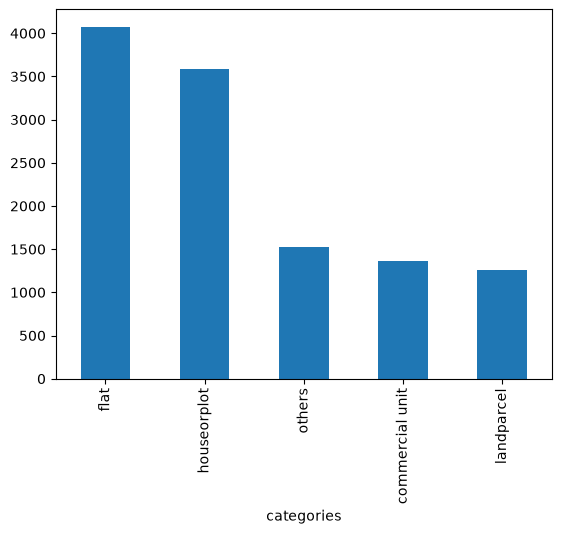

In [12]:
df["categories"].value_counts().plot(kind="bar")
plt.show()

In [15]:
pd.set_option("display.max_colwidth",None)
others_df = df[df["categories"] == "others"]

print(others_df["property_address"].sample(20))

8061                                                                                                                                                                                                                                                                                                                                                                       1839 Urban Estate Sec 32 A Chandigarh Road
3441                                                                                                                                                                                                                                                                                                                                                              mantri colony urf islampur near gov hospital sangli
4282                                                                                                                                                                                        

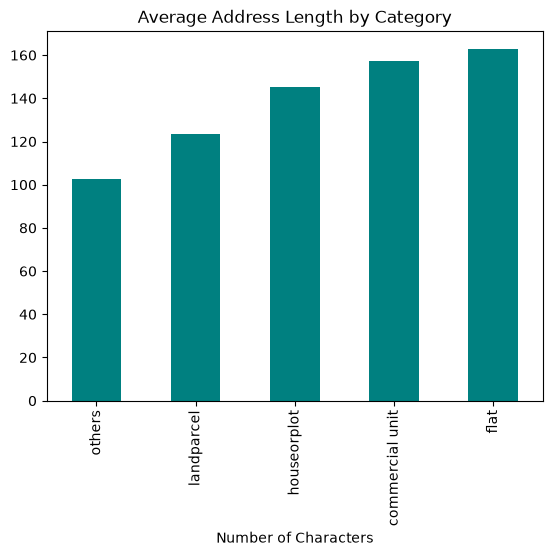

In [18]:
df["address_length"] = df["property_address"].astype(str).apply(len)
df.groupby("categories")["address_length"].mean().sort_values().plot(kind="bar",color="teal")
plt.title("Average Address Length by Category")
plt.xlabel("Number of Characters")
plt.show()

In [19]:
commercial_keywords = "shop|gala|commercial|office|showroom"
confusing_data = df[
    df["property_address"].str.contains(commercial_keywords,case=False,na=False) & 
    (df["categories"] != "commercial unit")
]

print(len(confusing_data))


349


In [21]:
confusing_data[["property_address","categories"]].head(10)

,property_address,categories
10,"Sy. No. 1388/1, Mandal Mangalagiri, Near Old Shiv Mandir, Chengalpattu, Tamil Nadu - 617093",landparcel
66,"S. No. 162/20 162/24, Senkulam Villagethirumangalam Taluk & Srothirumangalam Municipal,V.S.R.R. Prasadd.No. 25, Gandhiji Street, Thirumangala",houseorplot
82,"Gata No. 3928/3, P.S. Mangalagiri, Near Ganesh Temple, Gandhinagar, Gujarat - 778558",landparcel
95,"Plot No.-12,13,14 Situated At Vishnu Nagar Extension Yamuna Nagar, Haryana-135001 Jagadhari Workshop Hdfc Bank",houseorplot
130,"House No. 7, Ward No. 03, At. Kirmiti Village, Mouza Kirmiti (Bharkash),, Near Grampanchayat Office, Nagpur, Buttibori Midc Road, Tah Hingna Dist Nagpur, Maharashtra, India, 441122",houseorplot
202,"Commercial Prop No, 772/241-B, Krishna Vihar, Khasra No 947/966, Village Khadoli, Rohta Road Godwin Public School To Bypass, Meerut, Meerut, Uttar Pradesh,\n India, \n 250001",others
210,"Flat-303,Floor-3 Om Residency Tower A1 S No 323/2,333,342,Block 225Opp M M Vora Showroom,Bhvaishanv Park,Dabhoi Road Vadodara 390004 Gujarat",flat
231,"plot no. b-26, latur agro industris near midc office, barshi road, mouje baswatpur, latur industrial area, old midc, behind jaya hundai showroom old midc, behind jaya hundai showroom",houseorplot
266,"Khasra No. 84/9, Pargana Adalaj, Opposite Post Office, Kochi, Kerala - 508665",landparcel
269,"Khasra No.- 408 , , Dated Issue As On 18-08-2022. Which Is Issued\n By Development Officer Of Udaipurwati ,Niwasi - Giglala Kua , Gram -\n Bagora,Tehsil - Udaipurwati , Distt- Jhunjhunun , Rajasthan , 333307",houseorplot


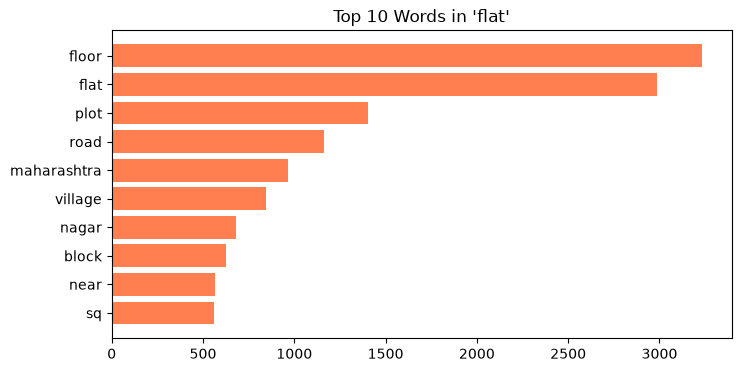

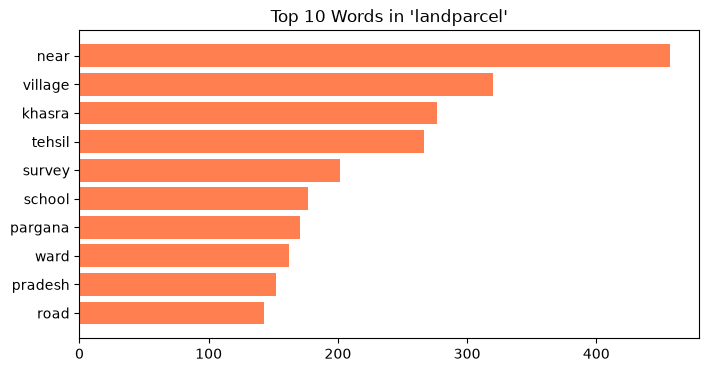

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_words(df, category, n=10):
    text_data = df[df['categories'] == category]['property_address'].astype(str)
    
    vec = CountVectorizer(stop_words='english', max_features=1000)
    word_counts = vec.fit_transform(text_data).sum(axis=0)
    
    words_freq = [(word, word_counts[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]
    
    words, counts = zip(*words_freq)
    plt.figure(figsize=(8, 4))
    plt.barh(words, counts, color='coral')
    plt.gca().invert_yaxis()
    plt.title(f"Top {n} Words in '{category}'")
    plt.show()

plot_top_words(df, 'flat')
plot_top_words(df, 'landparcel')

In [23]:
import re

def has_pincode(text):
    return bool(re.search(r'\b\d{6}\b', str(text)))

df['has_pincode'] = df['property_address'].apply(has_pincode)
pincode_stats = df.groupby('categories')['has_pincode'].mean() * 100

print("Percentage of addresses containing a 6-digit Pincode:\n")
print(pincode_stats.sort_values(ascending=False).round(1).astype(str) + '%')

Percentage of addresses containing a 6-digit Pincode:

categories
flat               76.5%
landparcel         71.3%
houseorplot        69.6%
others             57.3%
commercial unit    43.0%
Name: has_pincode, dtype: str


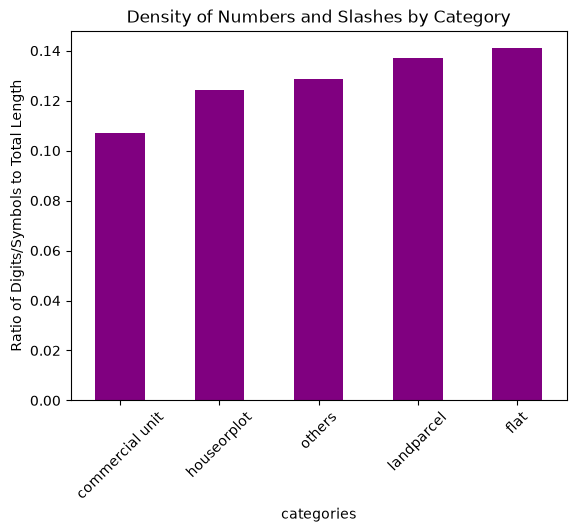

In [24]:
def math_density(text):
    text = str(text)
    if len(text) == 0: return 0
    math_chars = len(re.findall(r'[\d/\-]', text))
    return math_chars / len(text)

df['math_density'] = df['property_address'].apply(math_density)
df.groupby('categories')['math_density'].mean().sort_values().plot(kind='bar', color='purple')
plt.title("Density of Numbers and Slashes by Category")
plt.ylabel("Ratio of Digits/Symbols to Total Length")
plt.xticks(rotation=45)
plt.show()